# CLEARWARD – Financial Risk Intelligence & Self-Defense Platform

## What is CLEARWARD?

CLEARWARD is an AI-powered financial analytics platform that helps people understand the stock market using data, machine learning, and artificial intelligence.

The platform does **not** tell users which stock to buy or sell. Instead, it explains what is happening in the market, measures risk, and provides educational insights so users can make informed decisions.

---

# Why was CLEARWARD built?

Many new investors make decisions based on social media, news, or market rumours without understanding the actual risks.

CLEARWARD was developed to solve this problem by helping users:

- Understand historical stock performance.
- Learn market trends using technical indicators.
- Measure market risk.
- Read simple AI-generated explanations.
- Learn basic financial concepts.

The goal is to make financial analysis simple and easy to understand.

---

# How CLEARWARD Works

## Step 1 – Collect Historical Data

The platform downloads historical stock data such as:

- Open Price
- High Price
- Low Price
- Close Price
- Volume

### Why?

Historical data is the foundation for all further analysis.

### Example

A user searches for **HDFC Bank**. CLEARWARD downloads one year of historical trading data.

---

## Step 2 – Technical Analysis

The platform calculates indicators such as:

- EMA
- RSI
- MACD
- Bollinger Bands

### Why?

These indicators help understand:

- Market Trend
- Price Momentum
- Market Volatility

### Example

Instead of manually calculating these indicators, CLEARWARD generates them automatically and displays them through charts.

---

## Step 3 – Machine Learning

CLEARWARD uses Machine Learning models such as:

- MLP
- Random Forest

### Why?

The models learn from historical market patterns and classify the current market behaviour.

### Example

If today's market conditions are similar to previous historical patterns, the model identifies the corresponding market bias.

---

## Step 4 – Price Forecasting

CLEARWARD uses the ARIMA model.

### Why?

To estimate the possible short-term price movement based on historical closing prices.

### Example

The system forecasts the expected closing prices for the next five trading days.

---

## Step 5 – Risk Analysis

The platform calculates historical market volatility.

### Why?

Higher volatility means larger price fluctuations and therefore higher historical risk.

### Example

If HDFC Bank's price changes sharply every day, the volatility value increases.

---

# AI News Explanation (RAG)

## What is RAG?

RAG stands for **Retrieval-Augmented Generation**.

It combines **information retrieval** with **Artificial Intelligence**.

Instead of generating an answer only from the AI model's knowledge, the system first searches for relevant financial news and then uses that information to generate a factual explanation. :contentReference[oaicite:2]{index=2}

---

## How RAG Works

```
User searches HDFC Bank
        │
        ▼
Retrieve related financial news
        │
        ▼
Convert news into searchable vectors
        │
        ▼
Find the most relevant articles
        │
        ▼
AI reads the retrieved news
        │
        ▼
Generate a simple explanation
```

---

## Why is RAG used?

Stock prices often change because of real-world events.

Instead of only showing a graph, CLEARWARD also explains the possible reasons behind the movement using recent financial news.

---

## Example

Suppose HDFC Bank's stock price suddenly falls.

Without RAG:

> "The stock price decreased by 3%."

With RAG:

> "The stock price decreased after recent banking sector news and quarterly earnings announcements. This explanation is generated using relevant financial news articles."

This makes the analysis easier to understand.

---

# Summary Dashboard

Finally, CLEARWARD combines all the analysis into one dashboard.

The dashboard shows:

- Latest Stock Price
- Technical Indicators
- Machine Learning Results
- ARIMA Forecast
- Risk Analysis
- AI News Explanation

This allows users to understand the complete financial picture from a single screen.

---

# Overall Workflow

```
Historical Stock Data
        │
        ▼
Technical Indicators
        │
        ▼
Machine Learning Analysis
        │
        ▼
ARIMA Forecast
        │
        ▼
Risk Analysis
        │
        ▼
RAG News Retrieval
        │
        ▼
AI Explanation
        │
        ▼
Summary Dashboard
```

---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import yfinance as yf
from datetime import datetime

In [2]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [3]:
from statsmodels.tsa.arima.model import ARIMA

In [4]:
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [5]:
ticker="HDFCBANK.NS"

df=yf.download(ticker,period="1y",interval="1D",auto_adjust=True,progress=False)

In [6]:
df.head(),
# Convert MultiIndex columns to single-level columns
df.columns = df.columns.get_level_values(0)

In [7]:
df = df.dropna()

In [8]:
df.index.min().date(),df.index.max().date()

(datetime.date(2025, 8, 5), datetime.date(2026, 8, 5))

In [9]:
len(df)

250

In [10]:
df.shape ,df.isnull().sum(),display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Close,250.0,8.767433e+02,9.365792e+01,719.647400,7.802925e+02,9.110320e+02,9.683589e+02,9.930751e+02
High,250.0,8.841517e+02,9.318106e+01,729.435564,7.886439e+02,9.165164e+02,9.753680e+02,1.003896e+03
Low,250.0,8.700108e+02,9.409326e+01,714.827161,7.725750e+02,9.043919e+02,9.624811e+02,9.896320e+02
Open,250.0,8.764287e+02,9.408864e+01,718.122644,7.771710e+02,9.128765e+02,9.665759e+02,1.000945e+03
Volume,250.0,2.954479e+07,1.858131e+07,0.000000,1.751330e+07,2.552911e+07,3.775458e+07,1.716374e+08


((250, 5),
 Price
 Close     0
 High      0
 Low       0
 Open      0
 Volume    0
 dtype: int64,
 None)

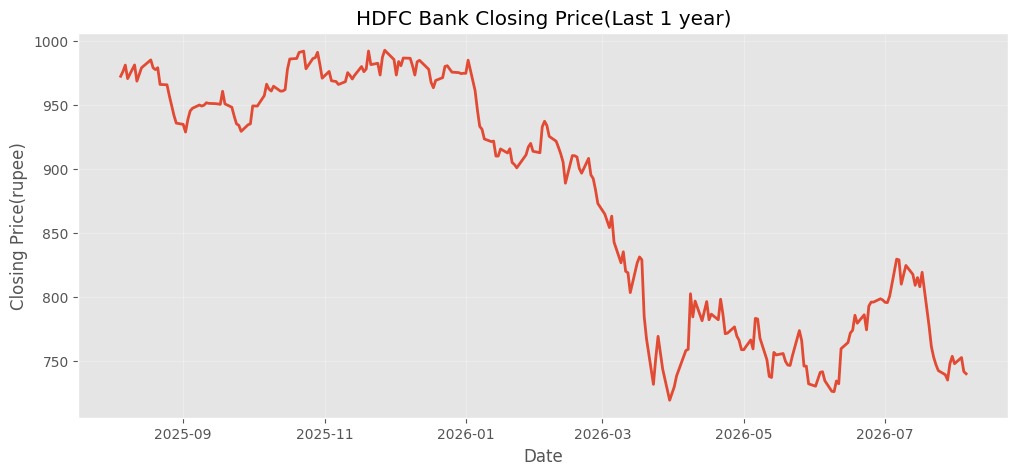

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.index,df['Close'],linewidth=2)
plt.title("HDFC Bank Closing Price(Last 1 year)")
plt.xlabel("Date")
plt.ylabel("Closing Price(rupee)")
plt.grid(alpha=0.3)
plt.show()


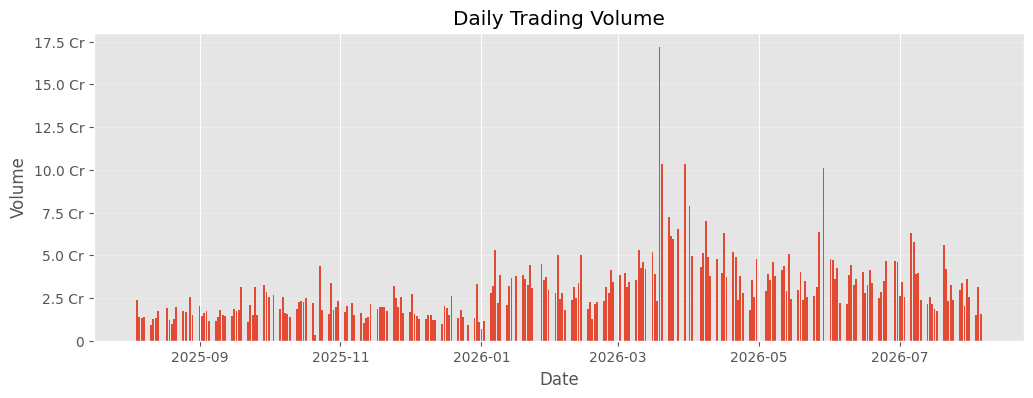

In [12]:
from matplotlib.ticker import FuncFormatter

def indian_volume(x, pos):
    if x >= 1e7:
        return f'{x/1e7:.1f} Cr'
    elif x >= 1e5:
        return f'{x/1e5:.1f} L'
    else:
        return f'{x:.0f}'

plt.figure(figsize=(12,4))

plt.bar(df.index, df["Volume"])

plt.gca().yaxis.set_major_formatter(FuncFormatter(indian_volume))

plt.title("Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [13]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [14]:
# Calculate Exponential Moving Averages
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()
#EMA = (Today's Price × α) + (Yesterday's EMA × (1 − α))

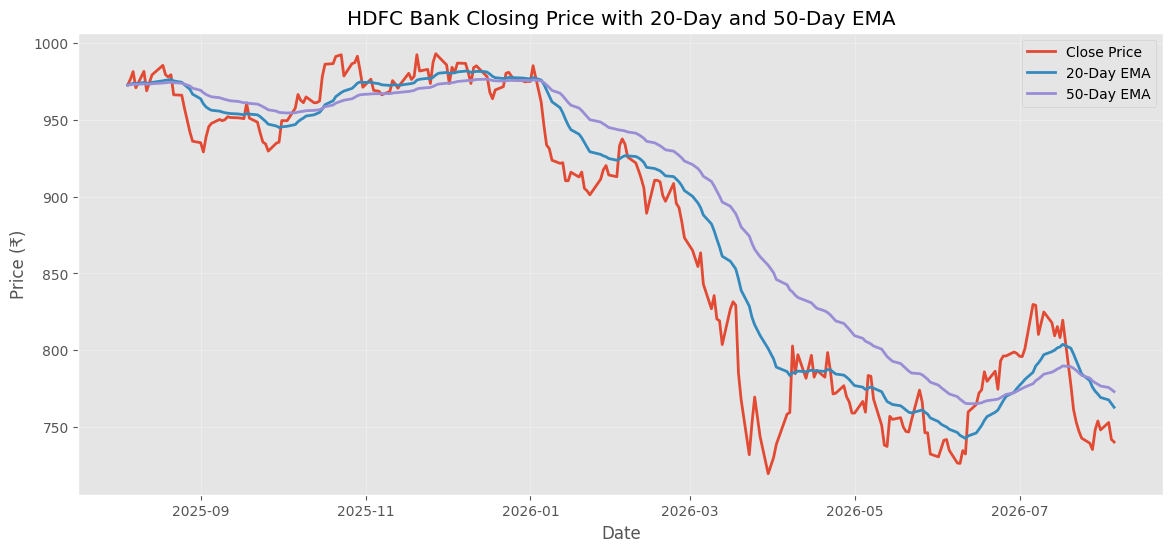

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Close Price", linewidth=2)
plt.plot(df.index, df["EMA_20"], label="20-Day EMA", linewidth=2)
plt.plot(df.index, df["EMA_50"], label="50-Day EMA", linewidth=2)

plt.title("HDFC Bank Closing Price with 20-Day and 50-Day EMA")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# Relative Strength Index (RSI)

## What is RSI?
## RSI is a momentum indicator that measures the strength of recent price
## movements. It ranges from 0 to 100 and compares the average gains to the
## average losses over a specified period (commonly 14 days).
#
## Formula:
##   RS  = Average Gain / Average Loss
##   RSI = 100 - (100 / (1 + RS))
#
## Interpretation:
##   RSI > 70  : Strong recent buying momentum.
##   RSI < 30  : Strong recent selling momentum.
##   RSI 30-70 : Neutral momentum.
#
## Note:
## RSI measures momentum, not future price direction. It should be interpreted
## alongside other indicators such as EMA and MACD.


In [16]:
# Calculate 14-Day RSI

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (100 / (1 + rs))

df[["Close", "RSI"]].tail()

Price,Close,RSI
Date,,
2026-07-30,753.950012,25.140043
2026-07-31,748.150024,25.353097
2026-08-03,753.000000,29.550376
2026-08-04,742.000000,24.291195
2026-08-05,740.299988,25.254713


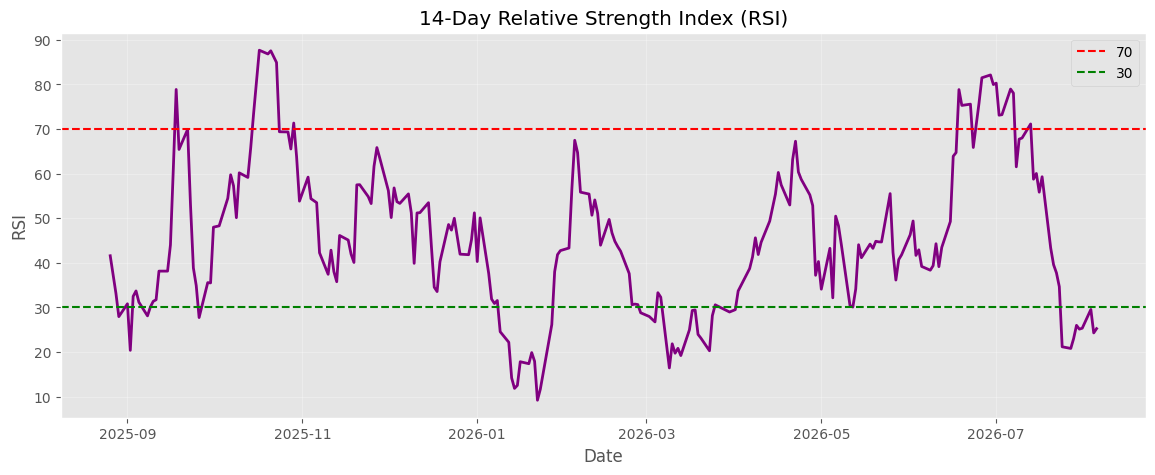

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["RSI"], color="purple", linewidth=2)

plt.axhline(70, color="red", linestyle="--", label="70")
plt.axhline(30, color="green", linestyle="--", label="30")

plt.title("14-Day Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 5.3 Moving Average Convergence Divergence (MACD)

## What is MACD?

The Moving Average Convergence Divergence (MACD) is a trend-following momentum indicator that measures the relationship between two Exponential Moving Averages (EMA).

It helps identify changes in trend strength and momentum by comparing a short-term EMA with a long-term EMA.

## Why is it used?

MACD helps determine whether recent price momentum is strengthening or weakening.

Unlike RSI, which measures the magnitude of price changes, MACD focuses on the relationship between short-term and long-term trends.

The three components of MACD are:

- **MACD Line:** Difference between the 12-day EMA and 26-day EMA.
- **Signal Line:** 9-day EMA of the MACD Line.
- **Histogram:** Difference between the MACD Line and Signal Line.

### Interpretation

The MACD indicator is interpreted by comparing the **MACD Line**, **Signal Line**, and **Histogram**.

| Condition | Interpretation |
|-----------|----------------|
| **MACD > Signal Line** | Recent price momentum is strengthening compared to the longer-term trend. |
| **MACD < Signal Line** | Recent price momentum is weakening compared to the longer-term trend. |
| **Histogram > 0** | The MACD Line is above the Signal Line, indicating positive momentum. |
| **Histogram < 0** | The MACD Line is below the Signal Line, indicating negative momentum. |
| **Histogram ≈ 0** | Momentum is balanced, with little difference between the MACD and Signal Line. |

### Key Observations

- A **rising MACD Line** indicates that short-term prices are increasing faster than long-term prices.
- A **falling MACD Line** indicates that short-term prices are weakening relative to the long-term trend.
- The **Histogram** measures the distance between the MACD Line and the Signal Line.
  - A **larger positive histogram** suggests stronger positive momentum.
  - A **larger negative histogram** suggests stronger negative momentum.
- When the MACD and Signal Line move close together, it indicates that market momentum is becoming less pronounced.

> **Note:** MACD is a trend and momentum indicator derived from historical prices. It should be interpreted alongside other indicators such as EMA, RSI, and Bollinger Bands, and not as a standalone investment signal.


In [18]:
# Calculate MACD Components

df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df["Histogram"] = df["MACD"] - df["Signal"]

df[["MACD", "Signal", "Histogram"]].tail()

Price,MACD,Signal,Histogram
Date,,,
2026-07-30,-11.683079,-4.818779,-6.864300
2026-07-31,-11.965716,-6.248167,-5.717549
2026-08-03,-11.663901,-7.331313,-4.332587
2026-08-04,-12.172007,-8.299452,-3.872555
2026-08-05,-12.566997,-9.152961,-3.414036


In [19]:
latest = df.iloc[-1]

print(f"MACD Line   : {latest['MACD']:.2f}")
print(f"Signal Line : {latest['Signal']:.2f}")
print(f"Histogram   : {latest['Histogram']:.2f}\n")

if latest["MACD"] > latest["Signal"]:
    print("Interpretation:")
    print("The MACD line is above the Signal line, indicating stronger recent momentum relative to the longer-term trend.")
else:
    print("Interpretation:")
    print("The MACD line is below the Signal line, indicating weaker recent momentum relative to the longer-term trend.")

MACD Line   : -12.57
Signal Line : -9.15
Histogram   : -3.41

Interpretation:
The MACD line is below the Signal line, indicating weaker recent momentum relative to the longer-term trend.


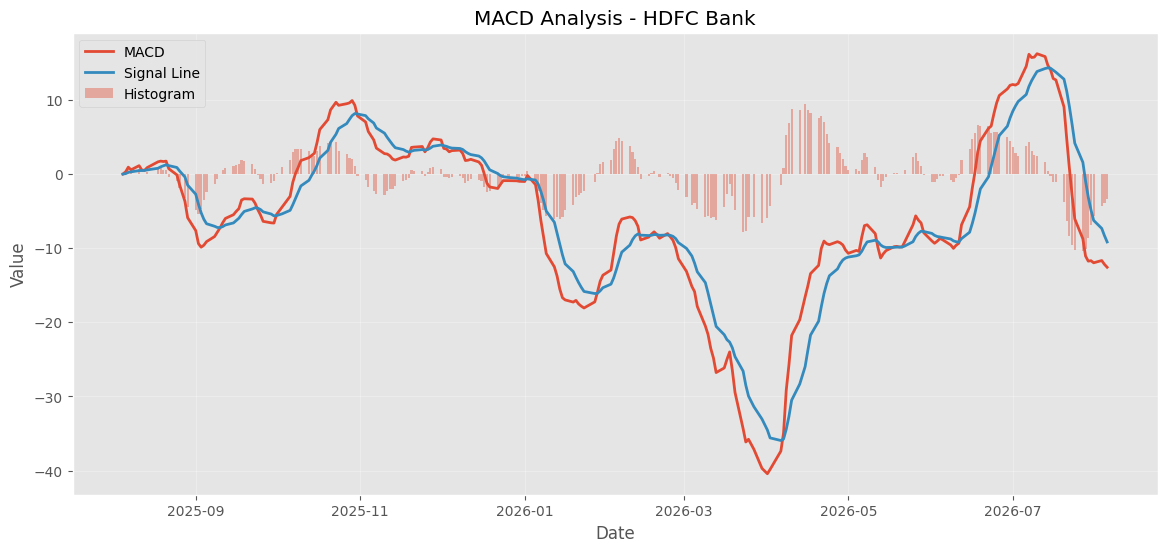

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["MACD"], label="MACD", linewidth=2)
plt.plot(df.index, df["Signal"], label="Signal Line", linewidth=2)

plt.bar(
    df.index,
    df["Histogram"],
    label="Histogram",
    alpha=0.4
)

plt.title("MACD Analysis - HDFC Bank")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 5.4 Bollinger Bands

## What are Bollinger Bands?

Bollinger Bands are a volatility indicator that consists of three lines:

- **Middle Band:** 20-Day Simple Moving Average (SMA)
- **Upper Band:** SMA + 2 × Standard Deviation
- **Lower Band:** SMA − 2 × Standard Deviation

The bands expand during periods of high volatility and contract during periods of low volatility.

## Why are they used?

Bollinger Bands help assess how far the current price deviates from its recent average.

They are commonly used to:

- Measure market volatility.
- Identify periods of unusually high or low price movement.
- Observe whether the price is trading near the upper or lower boundary of its recent trading range.

# Bollinger Bands

## What Are Bollinger Bands?

Bollinger Bands are a technical indicator used to measure **market volatility**. They consist of three bands plotted around the stock price:

- **Middle Band:** 20-Day Simple Moving Average (SMA)
- **Upper Band:** 20-Day SMA + (2 × Standard Deviation)
- **Lower Band:** 20-Day SMA − (2 × Standard Deviation)

As market volatility increases, the bands widen. When volatility decreases, the bands contract.

---

## Why Are Bollinger Bands Used?

Bollinger Bands help analyze:

- Price volatility
- Relative price position within its recent trading range
- Periods of expanding or contracting market activity

Unlike trend indicators, Bollinger Bands focus on how much prices fluctuate over time — not on the direction of the trend itself.

---

## Formula

**Middle Band**
$$
\text{Middle Band} = SMA_{20}
$$

**Upper Band**
$$
\text{Upper Band} = SMA_{20} + 2\sigma
$$

**Lower Band**
$$
\text{Lower Band} = SMA_{20} - 2\sigma
$$

Where:

- $SMA_{20}$ = 20-Day Simple Moving Average of the closing price
- $\sigma$ = 20-Day Standard Deviation of the closing price

---

## Interpretation

| Condition | Interpretation |
|---|---|
| Price near the Upper Band | The stock is trading near the upper limit of its recent price range. |
| Price near the Lower Band | The stock is trading near the lower limit of its recent price range. |
| Bands widening | Market volatility is increasing. |
| Bands narrowing | Market volatility is decreasing. |
| Price remains within the bands | The stock is trading within its normal historical volatility range. |

> **Note:** Bollinger Bands are volatility indicators. They describe the stock's recent price behaviour but should not be interpreted as direct buy or sell signals. They are most effective when combined with trend and momentum indicators such as EMA, RSI, and MACD.

In [21]:
# Calculate Bollinger Bands

df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["STD_20"] = df["Close"].rolling(window=20).std()

df["Upper_Band"] = df["SMA_20"] + (2 * df["STD_20"])
df["Lower_Band"] = df["SMA_20"] - (2 * df["STD_20"])

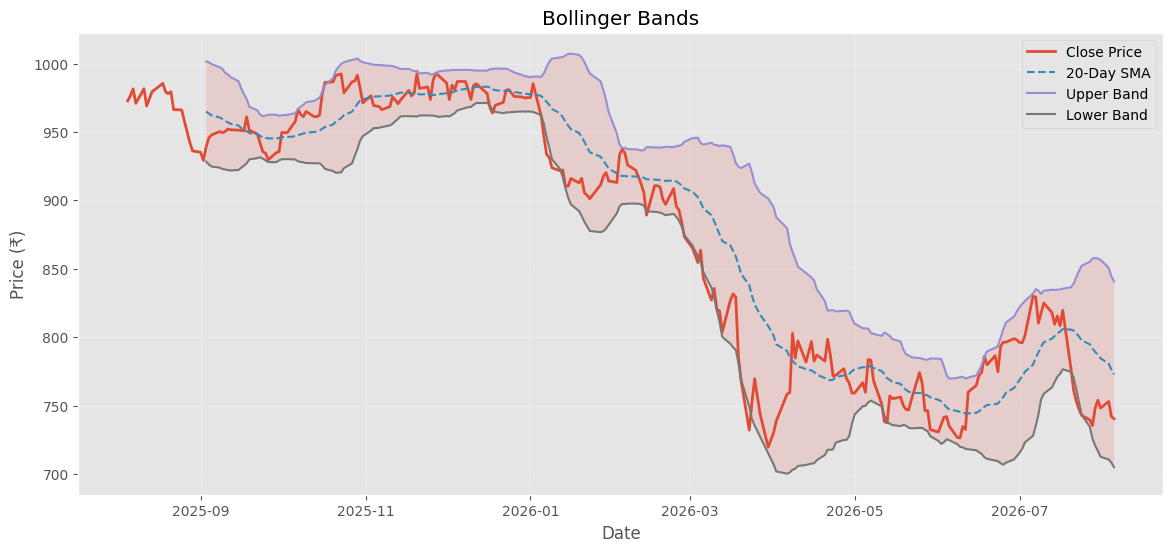

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Close Price", linewidth=2)
plt.plot(df.index, df["SMA_20"], label="20-Day SMA", linestyle="--")

plt.plot(df.index, df["Upper_Band"], label="Upper Band")
plt.plot(df.index, df["Lower_Band"], label="Lower Band")

plt.fill_between(
    df.index,
    df["Lower_Band"],
    df["Upper_Band"],
    alpha=0.15
)

plt.title("Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 6. Feature Engineering

## What is Feature Engineering?

Feature Engineering is the process of transforming raw market data into meaningful numerical variables (features) that can be used by Machine Learning models.

Instead of using only the stock's closing price, we provide the models with multiple indicators that capture different aspects of market behaviour.

---

## Why is it used?

Machine Learning algorithms cannot directly understand financial trends from raw price data. Feature engineering extracts useful information related to:

- Trend
- Momentum
- Volatility

These features help the models identify patterns and classify the current market regime.

---

## Features Used

| Feature | Description |
|---------|-------------|
| EMA 20 | Short-term trend |
| EMA 50 | Medium-term trend |
| RSI | Price momentum |
| MACD | Trend and momentum |
| Signal Line | Smoothed MACD |
| Bollinger Upper Band | Upper volatility boundary |
| Bollinger Lower Band | Lower volatility boundary |
| Volume | Daily trading activity |

These engineered features will be used as inputs for the Machine Learning models in the next section.

In [23]:
features = [
    "EMA_20",
    "EMA_50",
    "RSI",
    "MACD",
    "Signal",
    "Upper_Band",
    "Lower_Band",
    "Volume"
]

ml_df = df[features].dropna()

display(ml_df.tail())

Price,EMA_20,EMA_50,RSI,MACD,Signal,Upper_Band,Lower_Band,Volume
Date,,,,,,,,
2026-07-30,771.500449,777.885312,25.140043,-11.683079,-4.818779,857.425269,716.879730,35844392
2026-07-31,769.276599,776.719223,25.353097,-11.965716,-6.248167,856.538018,712.476985,25522483
2026-08-03,767.726447,775.789057,29.550376,-11.663901,-7.331313,850.682090,710.647915,14827841
2026-08-04,765.276309,774.463996,24.291195,-12.172007,-8.299452,844.409699,708.190307,31559802
2026-08-05,762.897612,773.124231,25.254713,-12.566997,-9.152961,840.747231,704.852775,15594437


In [24]:
# Create target variable

df["Next_Close"] = df["Close"].shift(-1)

df["Target"] = (df["Next_Close"] > df["Close"]).astype(int)

df = df.dropna()

df[["Close", "Next_Close", "Target"]].tail()

Price,Close,Next_Close,Target
Date,,,
2026-07-29,748.200012,753.950012,1
2026-07-30,753.950012,748.150024,0
2026-07-31,748.150024,753.000000,1
2026-08-03,753.000000,742.000000,0
2026-08-04,742.000000,740.299988,0


### Interpretation

For each trading day:

- If the next day's closing price is **higher**, the observation is assigned **Target = 1**.
- Otherwise, it is assigned **Target = 0**.

This converts a continuous price series into a binary classification problem, allowing algorithms such as **MLPClassifier** and **RandomForestClassifier** to learn patterns from historical technical indicators.

# 8. Market Regime Classification using MLP

## What is a Multi-Layer Perceptron (MLP)?

A Multi-Layer Perceptron (MLP) is a type of Artificial Neural Network (ANN) used for classification and prediction tasks. It consists of interconnected neurons organized into three types of layers:

- **Input Layer** – Receives the input features.
- **Hidden Layer(s)** – Learns complex relationships between features.
- **Output Layer** – Produces the predicted class.

Unlike traditional algorithms, an MLP can learn non-linear relationships between technical indicators and market behaviour.

---

## Why is it used?

Financial markets are influenced by multiple interacting factors. Indicators such as EMA, RSI, MACD, and Volume often have non-linear relationships that cannot always be captured using simple statistical models.

The MLP learns these relationships from historical data and classifies the expected market regime based on the engineered features.

---

## Model Configuration

| Parameter | Value |
|-----------|-------|
| Hidden Layers | (64, 32) |
| Activation Function | ReLU |
| Optimizer | Adam |
| Maximum Iterations | 500 |
| Random State | 42 |


In [25]:
X = df[features]
y = df["Target"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [27]:


model = MLPClassifier(
    hidden_layer_sizes=(64, 32,16),
    max_iter=1000,
    random_state=42
)

In [28]:
model.fit(X_train, y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [29]:
y_pred = model.predict(X_test)

In [30]:

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 56.52%


# 9. Random Forest Classifier

## What is a Random Forest?

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make a prediction. Each tree is trained on a different subset of the data, and the final prediction is determined by majority voting.

## Why is it used?

Random Forest is robust, handles non-linear relationships well, and is less prone to overfitting than a single decision tree. It also provides feature importance scores, helping identify which technical indicators contribute most to the prediction.

**Input Features**
- EMA 20
- EMA 50
- RSI
- MACD
- Signal
- Histogram
- Volume

**Output**
- **1** → Next day's closing price is higher.
- **0** → Next day's closing price is lower or unchanged.

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    random_state=42
)

In [32]:
rf_model.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
rf_pred = rf_model.predict(X_test)

In [34]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Accuracy : {rf_accuracy:.2%}")

Accuracy : 56.52%


In [35]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
3,MACD,0.140945
4,Signal,0.137381
6,Lower_Band,0.130677
7,Volume,0.122141
0,EMA_20,0.121427
2,RSI,0.118976
1,EMA_50,0.116445
5,Upper_Band,0.112008


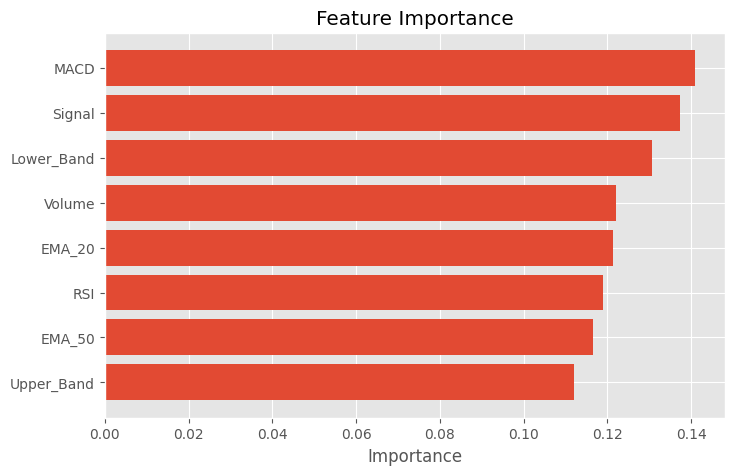

In [36]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [37]:
print(f"MLP Accuracy          : {accuracy:.2%}")
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

MLP Accuracy          : 56.52%
Random Forest Accuracy: 56.52%


In [38]:
if accuracy > rf_accuracy:
    print("Best Model : MLP Classifier")
else:
    print("Best Model : Random Forest")

Best Model : Random Forest


# 11. ARIMA Forecasting

## What is ARIMA?

ARIMA (AutoRegressive Integrated Moving Average) is a statistical time-series forecasting model that predicts future values using historical observations.

It analyzes past price movements to estimate the expected price trend over a future time period.

---

## Why is it used?

ARIMA is widely used in financial time-series forecasting because it models historical price behaviour and generates short-term forecasts.

In this notebook, ARIMA is used to forecast the closing price of HDFC Bank for the next **5 trading days**.
.


# ARIMA (p, d, q)

## What Is ARIMA?

ARIMA stands for **AutoRegressive Integrated Moving Average**. It's a forecasting model that predicts a number (like tomorrow's stock price) using only its **own past values** — no outside variables involved, just the series predicting itself.

---

## What Do p, d, q Mean?

| Letter | Name | Plain-English question it answers |
|---|---|---|
| **p** | AR order | How many past values do we look back at to help guess the next one? |
| **d** | Differencing order | How many times do we subtract yesterday's value from today's, just to flatten out the trend and make the series stable? |
| **q** | MA order | How many past prediction *mistakes* do we look back at and use to correct today's guess? |

**One line to remember it by:**
> Flatten the series *d* times, then predict each new point using *p* past values and *q* past errors.

---

## Example: ARIMA(1, 1, 0)

| Part | Plain meaning |
|---|---|
| **d = 1** | Don't work with raw prices — work with the *daily change* instead (today minus yesterday). Raw prices wander too much to predict directly; changes behave more consistently. |
| **p = 1** | To guess tomorrow's change, look just one day back — yesterday's change has a small carryover effect. |
| **q = 0** | No correction needed for past prediction errors — the past values alone are enough. |

**One line to say out loud in a viva:**
> ARIMA(1,1,0) means: instead of predicting the price directly, we predict the day-to-day change, and we use yesterday's change to help predict tomorrow's — nothing more complicated than that.

---

## Why This Order Is Often Chosen for Stock Data

- Raw prices aren't stationary (they trend/wander), so one difference (**d = 1**) settles them down.
- Once differenced, there's often just a small bit of momentum left from one day to the next — one AR term (**p = 1**) is enough to capture it.
- No need for the extra machinery of an MA term (**q = 0**).

It's the simplest model that still beats "tomorrow will look exactly like a coin flip."

In [39]:
arima = ARIMA(df["Close"], order=(5,1,0)).fit()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [40]:
forecast_result = arima.get_forecast(steps=5)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


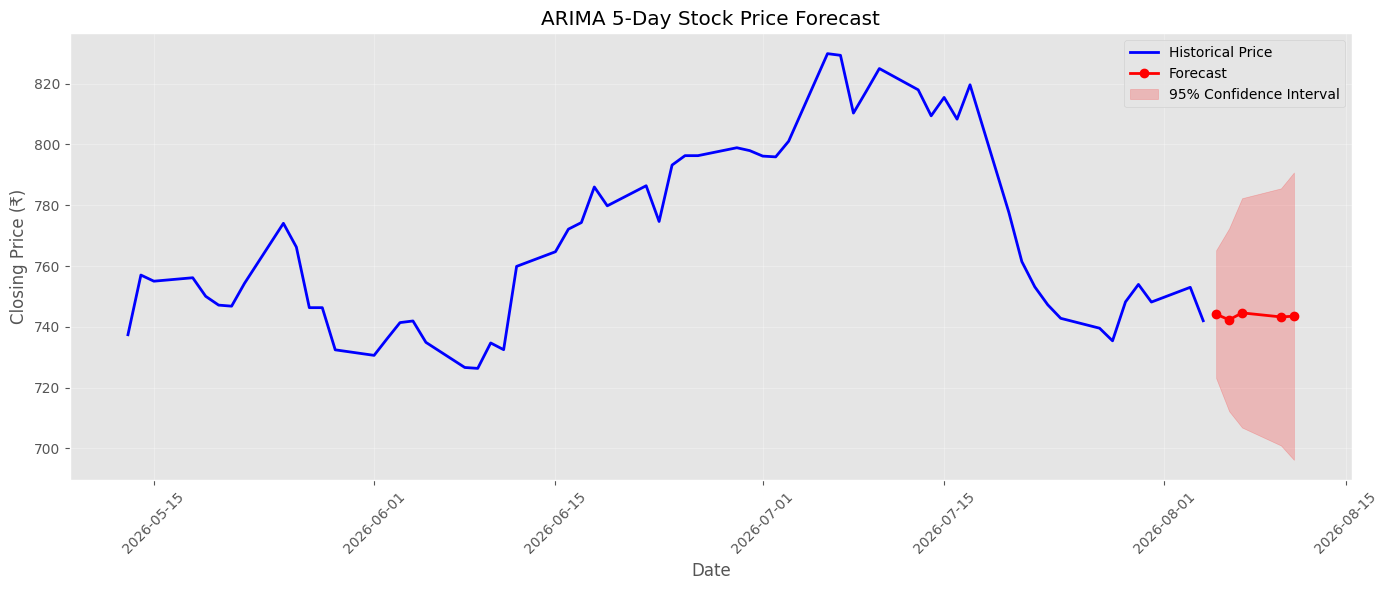

In [41]:
# Forecast for next 5 business days
forecast_result = arima.get_forecast(steps=5)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.BDay(1),
    periods=5,
    freq="B"
)

plt.figure(figsize=(14,6))

# Show last 60 trading days
plt.plot(
    df.index[-60:],
    df["Close"].tail(60),
    color="blue",
    linewidth=2,
    label="Historical Price"
)

# Forecast
plt.plot(
    future_dates,
    forecast,
    color="red",
    marker="o",
    linewidth=2,
    label="Forecast"
)

# 95% Confidence Interval
plt.fill_between(
    future_dates,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("ARIMA 5-Day Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast Price": forecast.values
})

forecast_df

,Date,Forecast Price
0,2026-08-05,744.150739
1,2026-08-06,742.304883
2,2026-08-07,744.590671
3,2026-08-10,743.260019
4,2026-08-11,743.502299


# 12. Risk Analysis

## What is Volatility?

Volatility measures how much a stock's price fluctuates over time. It is one of the most widely used indicators for assessing market risk.

Higher volatility indicates larger price movements, while lower volatility indicates relatively stable price movements.

---

## Why is it used?

Volatility helps investors understand the level of risk associated with a stock.

In this notebook, volatility is calculated using the standard deviation of daily returns over the past 30 trading days.

In [43]:
df["Daily_Return"] = df["Close"].pct_change()

In [44]:
df["Volatility"] = df["Daily_Return"].rolling(30).std()

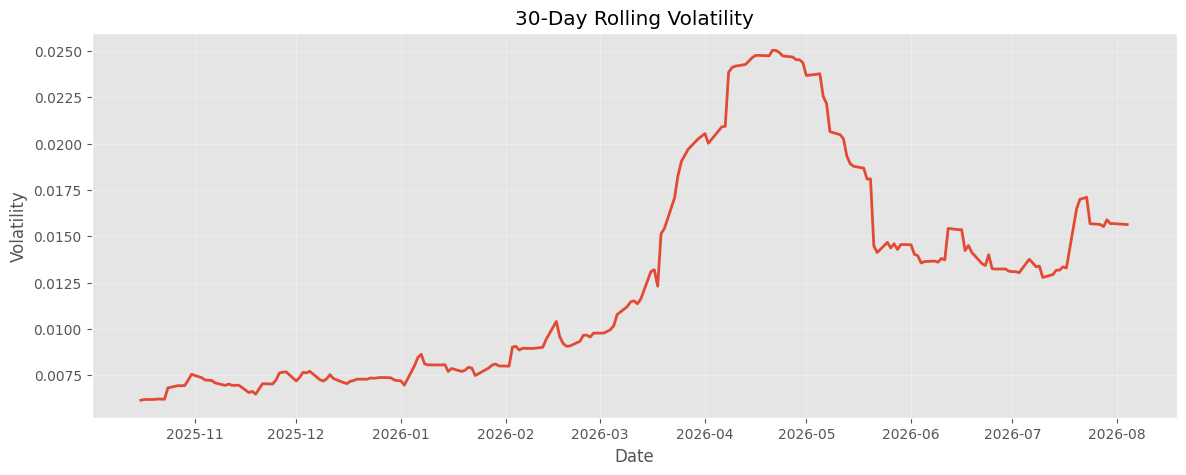

In [45]:
plt.figure(figsize=(14,5))

plt.plot(
    df.index,
    df["Volatility"],
    linewidth=2
)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)

plt.show()

In [46]:
latest_volatility = df["Volatility"].tail(1).values[0]

print(f"Latest Volatility : {latest_volatility:.4f}")

Latest Volatility : 0.0156
